In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Cell 2

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Bạn chưa bật GPU. Vào Runtime > Change runtime type > GPU")

CUDA available: True
GPU: Tesla T4


Cell 3

In [3]:
!pip install -q "numpy<2"
!pip install -q segmentation-models-pytorch albumentations opencv-python-headless tqdm matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 103.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 req

Cell 4

In [5]:
!pip uninstall -y numpy albumentations opencv-python opencv-python-headless

!pip install -q --no-cache-dir --force-reinstall "numpy==1.26.4"
!pip install -q --no-cache-dir "opencv-python-headless==4.10.0.84"
!pip install -q --no-cache-dir "albumentations==1.4.24"
!pip install -q --no-cache-dir "segmentation-models-pytorch==0.3.4"
!pip install -q --no-cache-dir tqdm matplotlib scikit-learn

Found existing installation: numpy 2.4.4
Uninstalling numpy-2.4.4:
  Successfully uninstalled numpy-2.4.4
Found existing installation: albumentations 2.0.8
Uninstalling albumentations-2.0.8:
  Successfully uninstalled albumentations-2.0.8
Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 300.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires opencv-python>=3.4.8.29, which is not installed.
albucore 0.0.24 requires opencv-python-

In [4]:
import os
import cv2
import time
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("Albumentations:", A.__version__)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

NumPy: 1.26.4
OpenCV: 4.10.0
Albumentations: 1.4.24
Torch: 2.10.0+cu128
CUDA: True


Cell 5

In [5]:
import os
import json
import random
import numpy as np
import torch

# =========================
# Dataset path
# =========================
DATA_DIR = "/content/drive/MyDrive/processed"

TRAIN_IMG_DIR = f"{DATA_DIR}/train/images"
TRAIN_MASK_DIR = f"{DATA_DIR}/train/masks"

VAL_IMG_DIR = f"{DATA_DIR}/val/images"
VAL_MASK_DIR = f"{DATA_DIR}/val/masks"

TEST_IMG_DIR = f"{DATA_DIR}/test/images"
TEST_MASK_DIR = f"{DATA_DIR}/test/masks"

# =========================
# Training config
# =========================
IMAGE_SIZE = 512
BATCH_SIZE = 4          # Nếu lỗi CUDA out of memory thì giảm xuống 2
EPOCHS = 50
LR = 1e-4

# Early stopping
PATIENCE = 8            # Nếu Val IoU không tăng sau 8 epoch thì dừng
MIN_DELTA = 1e-4        # Mức cải thiện tối thiểu để tính là tốt hơn

# Model config
ENCODER = "resnet50"    # Nếu máy yếu có thể đổi thành "resnet34"
ENCODER_WEIGHTS = "imagenet"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Save folder
SAVE_DIR = "/content/drive/MyDrive/tomato_unet_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = f"{SAVE_DIR}/best_unet_model.pth"
LAST_MODEL_PATH = f"{SAVE_DIR}/last_unet_model.pth"
HISTORY_PATH = f"{SAVE_DIR}/unet_training_history.json"

# Seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("Dataset root:", DATA_DIR)
print("Save dir:", SAVE_DIR)

Device: cuda
Dataset root: /content/drive/MyDrive/processed
Save dir: /content/drive/MyDrive/tomato_unet_checkpoints


Cell 6

In [6]:
from pathlib import Path

def count_image_files(folder):
    exts = [".jpg", ".jpeg", ".png", ".bmp", ".JPG", ".JPEG", ".PNG", ".BMP"]
    folder = Path(folder)

    if not folder.exists():
        print("Không tồn tại:", folder)
        return 0

    return len([f for f in folder.glob("*") if f.suffix in exts])

print("Train images:", count_image_files(TRAIN_IMG_DIR))
print("Train masks :", count_image_files(TRAIN_MASK_DIR))

print("Val images  :", count_image_files(VAL_IMG_DIR))
print("Val masks   :", count_image_files(VAL_MASK_DIR))

print("Test images :", count_image_files(TEST_IMG_DIR))
print("Test masks  :", count_image_files(TEST_MASK_DIR))

Train images: 5634
Train masks : 5618
Val images  : 1207
Val masks   : 1219
Test images : 1229
Test masks  : 1210


Cell 7

In [7]:
class TomatoSegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.transform = transform

        image_exts = [".jpg", ".jpeg", ".png", ".bmp", ".JPG", ".JPEG", ".PNG", ".BMP"]

        image_paths = [
            p for p in self.images_dir.glob("*")
            if p.suffix in image_exts
        ]

        mask_paths = [
            p for p in self.masks_dir.glob("*")
            if p.suffix in image_exts
        ]

        # Map mask theo tên file không tính đuôi
        # Ví dụ: abc.jpg và abc.png vẫn được xem là cùng cặp
        mask_map = {p.stem: p for p in mask_paths}

        self.pairs = []
        missing_masks = 0

        for img_path in image_paths:
            if img_path.stem in mask_map:
                self.pairs.append((img_path, mask_map[img_path.stem]))
            else:
                missing_masks += 1

        self.pairs = sorted(self.pairs, key=lambda x: x[0].name)

        print("Images found:", len(image_paths))
        print("Masks found :", len(mask_paths))
        print("Valid pairs :", len(self.pairs))
        print("Missing masks skipped:", missing_masks)

        if len(self.pairs) == 0:
            raise RuntimeError("Không tìm thấy cặp image-mask hợp lệ. Kiểm tra lại đường dẫn dataset.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        image = cv2.imread(str(img_path))
        if image is None:
            raise RuntimeError(f"Không đọc được ảnh: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise RuntimeError(f"Không đọc được mask: {mask_path}")

        # Đưa mask về binary: 0 hoặc 1
        mask = (mask > 127).astype("float32")

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # Sau ToTensorV2, image: [3, H, W], mask: [H, W]
        if len(mask.shape) == 2:
            mask = mask.unsqueeze(0)

        mask = mask.float()

        return image, mask

Cell 8

In [8]:
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
        p=0.3
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

Cell 9

In [9]:
train_dataset = TomatoSegmentationDataset(
    images_dir=TRAIN_IMG_DIR,
    masks_dir=TRAIN_MASK_DIR,
    transform=train_transform
)

val_dataset = TomatoSegmentationDataset(
    images_dir=VAL_IMG_DIR,
    masks_dir=VAL_MASK_DIR,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

Images found: 5634
Masks found : 5618
Valid pairs : 5618
Missing masks skipped: 16
Images found: 1207
Masks found : 1219
Valid pairs : 1203
Missing masks skipped: 4
Train dataset: 5618
Val dataset  : 1203
Train batches: 1405
Val batches  : 301


Cell 10

Image batch: torch.Size([4, 3, 512, 512])
Mask batch : torch.Size([4, 1, 512, 512])


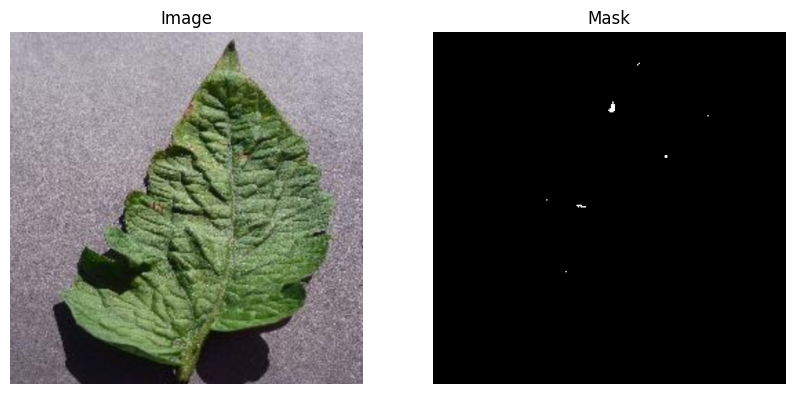

In [10]:
images, masks = next(iter(train_loader))

print("Image batch:", images.shape)
print("Mask batch :", masks.shape)

img = images[0].permute(1, 2, 0).cpu().numpy()
mask = masks[0][0].cpu().numpy()

# Unnormalize để hiển thị ảnh đúng màu
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img = std * img + mean
img = np.clip(img, 0, 1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

Cell 11

In [11]:
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=3,
    classes=1,
    activation=None
)

model = model.to(DEVICE)

print("Model: U-Net")
print("Encoder:", ENCODER)
print("Device:", DEVICE)

Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 414MB/s]


Model: U-Net
Encoder: resnet50
Device: cuda


Cell 12

In [12]:
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

def loss_fn(logits, masks):
    bce = bce_loss(logits, masks)
    dice = dice_loss(logits, masks)
    return bce + dice


def calculate_metrics(logits, masks, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    masks = masks.float()

    intersection = (preds * masks).sum(dim=(1, 2, 3))
    pred_sum = preds.sum(dim=(1, 2, 3))
    mask_sum = masks.sum(dim=(1, 2, 3))
    union = pred_sum + mask_sum - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred_sum + mask_sum + eps)

    tp = intersection
    fp = pred_sum - intersection
    fn = mask_sum - intersection

    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)

    accuracy = (preds == masks).float().mean(dim=(1, 2, 3))

    return {
        "iou": iou.mean().item(),
        "dice": dice.mean().item(),
        "accuracy": accuracy.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item()
    }


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

print("Loss: BCEWithLogitsLoss + DiceLoss")
print("Optimizer: AdamW")
print("LR:", LR)

Loss: BCEWithLogitsLoss + DiceLoss
Optimizer: AdamW
LR: 0.0001


/tmp/ipykernel_1896/354942499.py:58: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


Cell 13

In [13]:
class EarlyStopping:
    def __init__(self, patience=8, min_delta=1e-4, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode

        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def is_improvement(self, current_score):
        if self.best_score is None:
            return True

        if self.mode == "max":
            return current_score > self.best_score + self.min_delta
        else:
            return current_score < self.best_score - self.min_delta

    def step(self, current_score):
        if self.is_improvement(current_score):
            self.best_score = current_score
            self.counter = 0
            return True
        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.should_stop = True

            return False


early_stopping = EarlyStopping(
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    mode="max"
)

print("Early stopping patience:", PATIENCE)
print("Early stopping min_delta:", MIN_DELTA)

Early stopping patience: 8
Early stopping min_delta: 0.0001


Cell 14

In [14]:
def train_one_epoch(model, loader, optimizer):
    model.train()

    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    total_acc = 0.0
    total_precision = 0.0
    total_recall = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, masks in progress_bar:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            logits = model(images)
            loss = loss_fn(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        metrics = calculate_metrics(logits.detach(), masks)

        total_loss += loss.item()
        total_iou += metrics["iou"]
        total_dice += metrics["dice"]
        total_acc += metrics["accuracy"]
        total_precision += metrics["precision"]
        total_recall += metrics["recall"]

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "iou": f"{metrics['iou']:.4f}",
            "dice": f"{metrics['dice']:.4f}"
        })

    n = len(loader)

    return {
        "loss": total_loss / n,
        "iou": total_iou / n,
        "dice": total_dice / n,
        "accuracy": total_acc / n,
        "precision": total_precision / n,
        "recall": total_recall / n
    }

Cell 15

In [15]:
@torch.no_grad()
def validate_one_epoch(model, loader):
    model.eval()

    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    total_acc = 0.0
    total_precision = 0.0
    total_recall = 0.0

    progress_bar = tqdm(loader, desc="Validation", leave=False)

    for images, masks in progress_bar:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            logits = model(images)
            loss = loss_fn(logits, masks)

        metrics = calculate_metrics(logits, masks)

        total_loss += loss.item()
        total_iou += metrics["iou"]
        total_dice += metrics["dice"]
        total_acc += metrics["accuracy"]
        total_precision += metrics["precision"]
        total_recall += metrics["recall"]

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "iou": f"{metrics['iou']:.4f}",
            "dice": f"{metrics['dice']:.4f}"
        })

    n = len(loader)

    return {
        "loss": total_loss / n,
        "iou": total_iou / n,
        "dice": total_dice / n,
        "accuracy": total_acc / n,
        "precision": total_precision / n,
        "recall": total_recall / n
    }

Cell 16

In [16]:
best_iou = 0.0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_iou": [],
    "val_iou": [],
    "train_dice": [],
    "val_dice": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "lr": []
}

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    print(f"\nEpoch [{epoch}/{EPOCHS}]")
    print("-" * 60)

    train_metrics = train_one_epoch(model, train_loader, optimizer)
    val_metrics = validate_one_epoch(model, val_loader)

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(val_metrics["iou"])

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])

    history["train_iou"].append(train_metrics["iou"])
    history["val_iou"].append(val_metrics["iou"])

    history["train_dice"].append(train_metrics["dice"])
    history["val_dice"].append(val_metrics["dice"])

    history["train_accuracy"].append(train_metrics["accuracy"])
    history["val_accuracy"].append(val_metrics["accuracy"])

    history["train_precision"].append(train_metrics["precision"])
    history["val_precision"].append(val_metrics["precision"])

    history["train_recall"].append(train_metrics["recall"])
    history["val_recall"].append(val_metrics["recall"])

    history["lr"].append(current_lr)

    elapsed = time.time() - start_time

    print(
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"IoU: {train_metrics['iou']:.4f} | "
        f"Dice: {train_metrics['dice']:.4f} | "
        f"Acc: {train_metrics['accuracy']:.4f}"
    )

    print(
        f"Val   Loss: {val_metrics['loss']:.4f} | "
        f"IoU: {val_metrics['iou']:.4f} | "
        f"Dice: {val_metrics['dice']:.4f} | "
        f"Acc: {val_metrics['accuracy']:.4f}"
    )

    print(
        f"Val Precision: {val_metrics['precision']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f}"
    )

    print(f"LR: {current_lr:.8f}")
    print(f"Time: {elapsed:.2f}s")

    # Lưu last checkpoint
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_iou": best_iou,
        "history": history,
        "encoder": ENCODER,
        "encoder_weights": ENCODER_WEIGHTS,
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "lr": LR
    }, LAST_MODEL_PATH)

    # Early stopping kiểm tra theo Val IoU
    improved = early_stopping.step(val_metrics["iou"])

    if improved:
        best_iou = val_metrics["iou"]

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_iou": best_iou,
            "history": history,
            "encoder": ENCODER,
            "encoder_weights": ENCODER_WEIGHTS,
            "image_size": IMAGE_SIZE,
            "batch_size": BATCH_SIZE,
            "lr": LR
        }, BEST_MODEL_PATH)

        print(f"Best model saved: {BEST_MODEL_PATH}")
        print(f"Best Val IoU: {best_iou:.4f}")
    else:
        print(
            f"No improvement. Early stopping counter: "
            f"{early_stopping.counter}/{early_stopping.patience}"
        )

    # Lưu history ra JSON sau mỗi epoch
    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=4)

    if early_stopping.should_stop:
        print("\nEarly stopping activated.")
        print(f"Stopped at epoch {epoch}.")
        print(f"Best Val IoU: {best_iou:.4f}")
        break

print("\nTraining finished.")
print("Best Val IoU:", best_iou)
print("Best model path:", BEST_MODEL_PATH)
print("Last model path:", LAST_MODEL_PATH)
print("History path:", HISTORY_PATH)


Epoch [1/50]
------------------------------------------------------------


Training:   0%|          | 0/1405 [00:00<?, ?it/s]

/tmp/ipykernel_1896/328230529.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):


Validation:   0%|          | 0/301 [00:00<?, ?it/s]

/tmp/ipykernel_1896/3887903170.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):


...

Validation:   0%|          | 0/301 [00:00<?, ?it/s]

Train Loss: 0.3506 | IoU: 0.4079 | Dice: 0.4921 | Acc: 0.9927
Val   Loss: 0.4414 | IoU: 0.4290 | Dice: 0.5112 | Acc: 0.9933
Val Precision: 0.7880 | Val Recall: 0.5275
LR: 0.00000625
Time: 286.98s
No improvement. Early stopping counter: 7/8

Epoch [45/50]
------------------------------------------------------------


Training:   0%|          | 0/1405 [00:00<?, ?it/s]

Validation:   0%|          | 0/301 [00:00<?, ?it/s]

Train Loss: 0.3411 | IoU: 0.4075 | Dice: 0.4913 | Acc: 0.9926
Val   Loss: 0.4485 | IoU: 0.4202 | Dice: 0.5020 | Acc: 0.9933
Val Precision: 0.8025 | Val Recall: 0.5090
LR: 0.00000625
Time: 297.76s
No improvement. Early stopping counter: 8/8

Early stopping activated.
Stopped at epoch 45.
Best Val IoU: 0.4320

Training finished.
Best Val IoU: 0.4319887686634465
Best model path: /content/drive/MyDrive/tomato_unet_checkpoints/best_unet_model.pth
Last model path: /content/drive/MyDrive/tomato_unet_checkpoints/last_unet_model.pth
History path: /content/drive/MyDrive/tomato_unet_checkpoints/unet_training_history.json


Cell 17

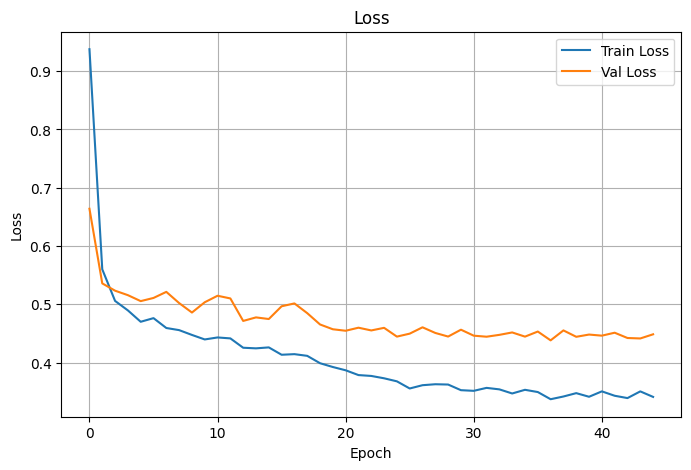

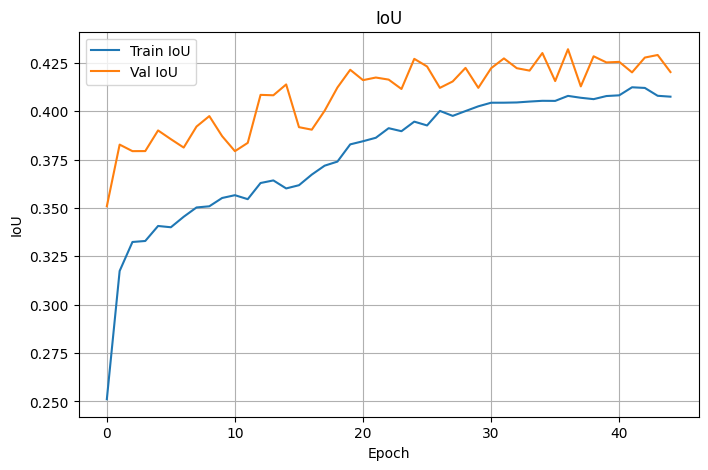

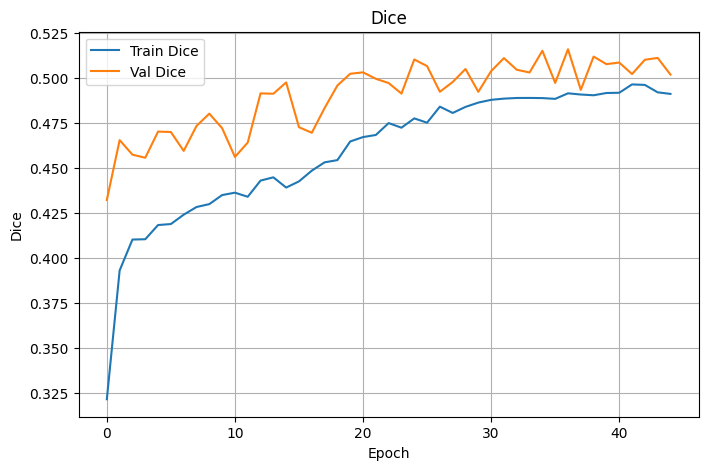

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_iou"], label="Train IoU")
plt.plot(history["val_iou"], label="Val IoU")
plt.title("IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_dice"], label="Train Dice")
plt.plot(history["val_dice"], label="Val Dice")
plt.title("Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.grid(True)
plt.show()

Cell 18

In [18]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

print("Loaded best model from:", BEST_MODEL_PATH)
print("Best IoU:", checkpoint["best_iou"])
print("Best epoch:", checkpoint["epoch"])

Loaded best model from: /content/drive/MyDrive/tomato_unet_checkpoints/best_unet_model.pth
Best IoU: 0.4319887686634465
Best epoch: 37


Cell 19

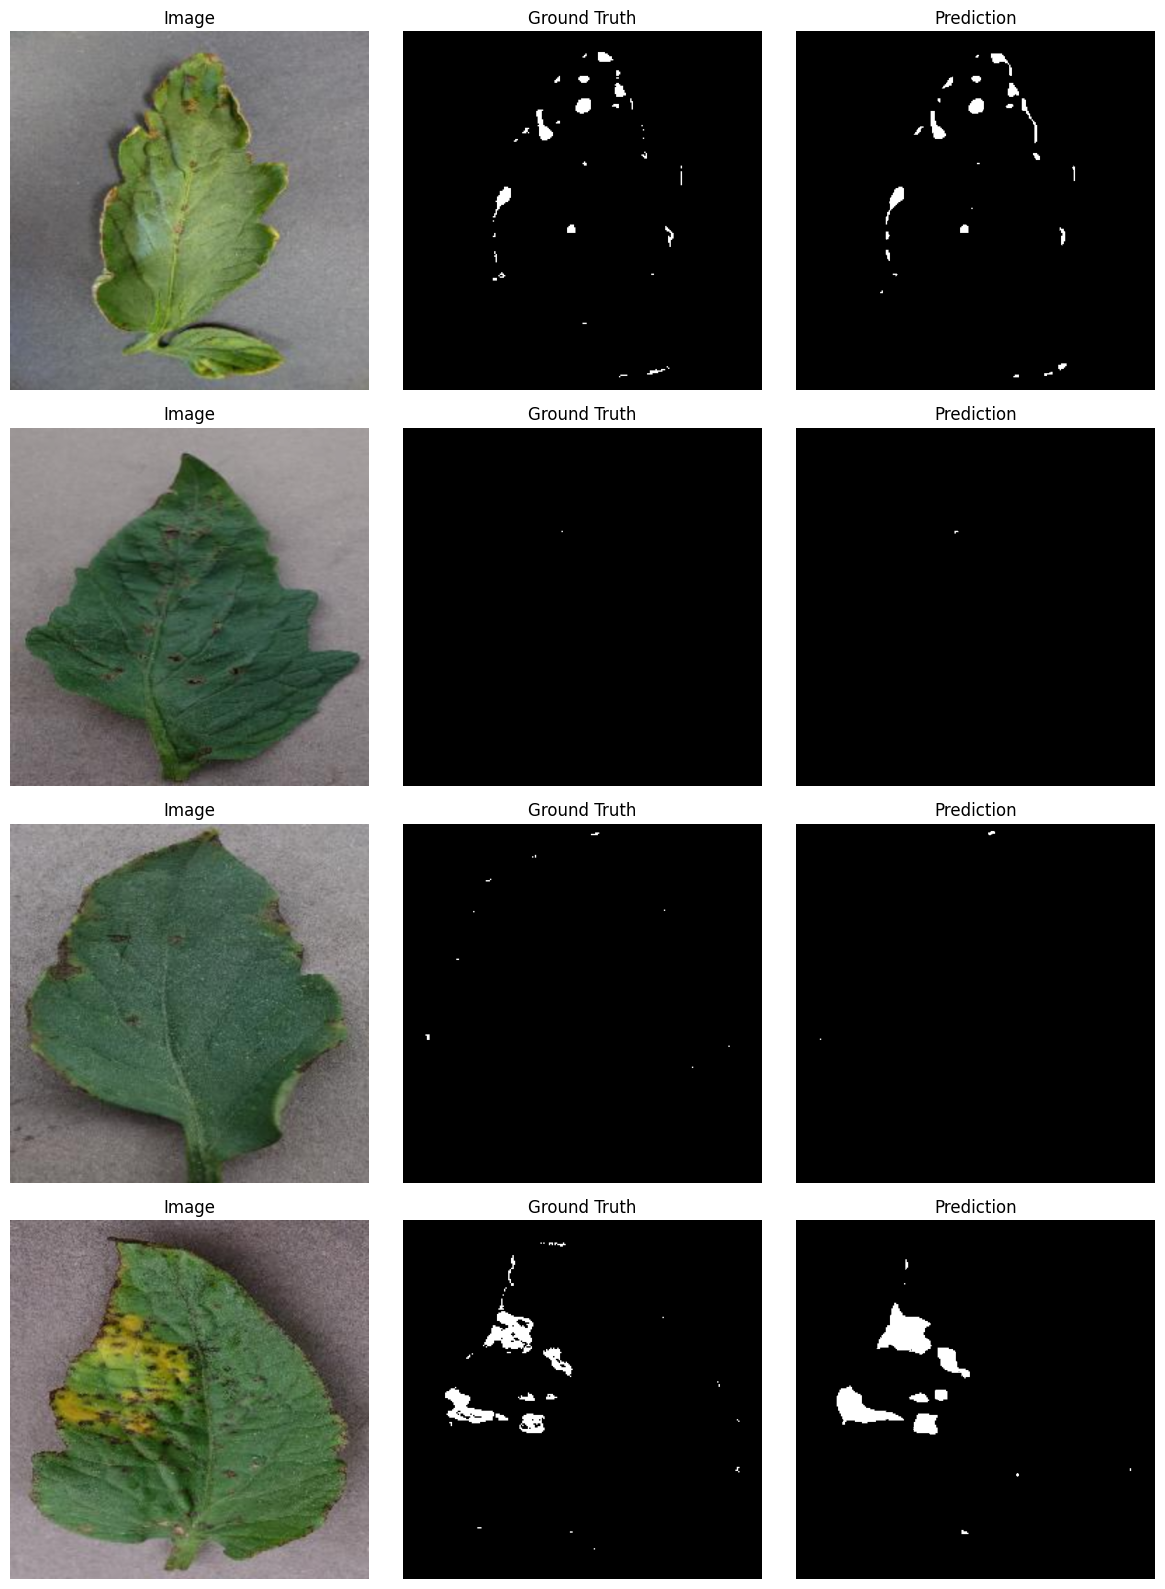

In [19]:
@torch.no_grad()
def show_predictions(model, loader, num_samples=4, threshold=0.5):
    model.eval()

    images, masks = next(iter(loader))

    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    logits = model(images)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    n = min(num_samples, images.size(0))

    plt.figure(figsize=(12, 4 * n))

    for i in range(n):
        img = images[i].permute(1, 2, 0).numpy()
        img = std * img + mean
        img = np.clip(img, 0, 1)

        gt_mask = masks[i][0].numpy()
        pred_mask = preds[i][0].numpy()

        plt.subplot(n, 3, i * 3 + 1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        plt.imshow(gt_mask, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(model, val_loader, num_samples=4, threshold=0.5)

Cell 20

In [20]:
test_dataset = TomatoSegmentationDataset(
    images_dir=TEST_IMG_DIR,
    masks_dir=TEST_MASK_DIR,
    transform=val_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_metrics = validate_one_epoch(model, test_loader)

print("Test results")
print("-" * 40)
print("Loss     :", round(test_metrics["loss"], 4))
print("IoU      :", round(test_metrics["iou"], 4))
print("Dice     :", round(test_metrics["dice"], 4))
print("Accuracy :", round(test_metrics["accuracy"], 4))
print("Precision:", round(test_metrics["precision"], 4))
print("Recall   :", round(test_metrics["recall"], 4))

Images found: 1229
Masks found : 1210
Valid pairs : 1210
Missing masks skipped: 19


Validation:   0%|          | 0/303 [00:00<?, ?it/s]

/tmp/ipykernel_1896/3887903170.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):


Test results
----------------------------------------
Loss     : 0.435
IoU      : 0.4267
Dice     : 0.5155
Accuracy : 0.9923
Precision: 0.7473
Recall   : 0.5386


Cell 21

In [21]:
WEIGHTS_ONLY_PATH = f"{SAVE_DIR}/unet_weights_only.pth"

torch.save(model.state_dict(), WEIGHTS_ONLY_PATH)

print("Saved weights only to:")
print(WEIGHTS_ONLY_PATH)

Saved weights only to:
/content/drive/MyDrive/tomato_unet_checkpoints/unet_weights_only.pth


In [22]:
import os
import json
import shutil
from pathlib import Path

# Folder checkpoint hiện tại của bạn
CHECKPOINT_DIR = Path("/content/drive/MyDrive/tomato_unet_checkpoints")

# Folder gom kết quả
RESULT_DIR = Path("/content/unet_final_results")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Checkpoint dir:", CHECKPOINT_DIR)
print("Result dir:", RESULT_DIR)

Checkpoint dir: /content/drive/MyDrive/tomato_unet_checkpoints
Result dir: /content/unet_final_results


In [23]:
files_to_copy = [
    "best_unet_model.pth",
    "last_unet_model.pth",
    "unet_weights_only.pth",
    "unet_training_history.json"
]

for filename in files_to_copy:
    src = CHECKPOINT_DIR / filename
    dst = RESULT_DIR / filename

    if src.exists():
        shutil.copy2(src, dst)
        print("Copied:", filename)
    else:
        print("Missing:", filename)

Copied: best_unet_model.pth
Copied: last_unet_model.pth
Copied: unet_weights_only.pth
Copied: unet_training_history.json


In [24]:
metrics_summary = {
    "model": "U-Net",
    "encoder": "ResNet50",
    "image_size": 512,
    "best_validation_iou": 0.4319887686634465,
    "best_epoch": 37,
    "test_results": {
        "loss": 0.4350,
        "iou": 0.4267,
        "dice": 0.5155,
        "accuracy": 0.9923,
        "precision": 0.7473,
        "recall": 0.5386
    },
    "checkpoint_files": {
        "best_model": "best_unet_model.pth",
        "last_model": "last_unet_model.pth",
        "weights_only": "unet_weights_only.pth",
        "history": "unet_training_history.json"
    }
}

metrics_path = RESULT_DIR / "unet_metrics_summary.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=4, ensure_ascii=False)

print("Saved:", metrics_path)

Saved: /content/unet_final_results/unet_metrics_summary.json


In [25]:
readme_text = """
# U-Net Tomato Leaf Segmentation Results

## Model Information

- Model: U-Net
- Encoder: ResNet50
- Framework: PyTorch + segmentation_models_pytorch
- Task: Binary segmentation vùng bệnh trên lá cà chua
- Image size: 512x512
- Output: 1-channel binary mask

## Best Validation Result

- Best Validation IoU: 0.4319887686634465
- Best Epoch: 37

## Test Results

- Test Loss: 0.4350
- Test IoU: 0.4267
- Test Dice: 0.5155
- Test Accuracy: 0.9923
- Test Precision: 0.7473
- Test Recall: 0.5386

## Files Included

- best_unet_model.pth
  - Checkpoint tốt nhất theo validation IoU.
  - Nên dùng file này cho backend.

- last_unet_model.pth
  - Checkpoint cuối cùng khi training dừng.

- unet_weights_only.pth
  - Chỉ chứa model state_dict.
  - Dùng khi backend tự khai báo kiến trúc model.

- unet_training_history.json
  - Lịch sử train/validation loss, IoU, Dice, Accuracy, Precision, Recall.

- unet_metrics_summary.json
  - Tổng hợp kết quả chính.

- loss_curve.png
  - Biểu đồ Train Loss và Validation Loss.

- iou_curve.png
  - Biểu đồ Train IoU và Validation IoU.

- dice_curve.png
  - Biểu đồ Train Dice và Validation Dice.

## Backend Recommendation

Nên dùng:

webapp/backend/models/best_unet_model.pth

Khi load backend, cần tạo lại model:

smp.Unet(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None
)

Sau đó load:

checkpoint = torch.load("best_unet_model.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
"""

readme_path = RESULT_DIR / "README_unet_results.txt"

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

print("Saved:", readme_path)

Saved: /content/unet_final_results/README_unet_results.txt


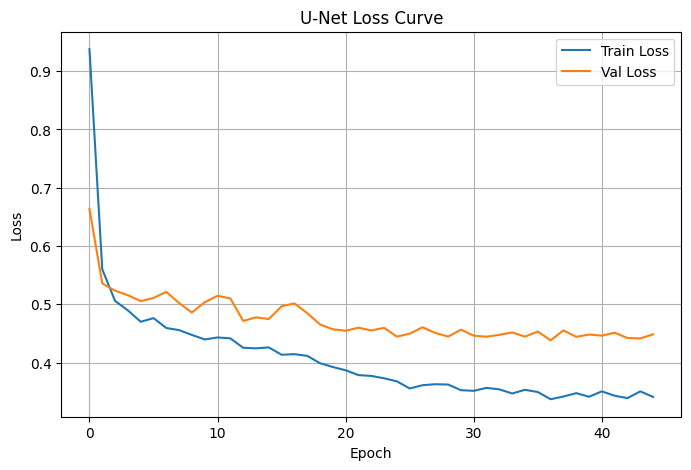

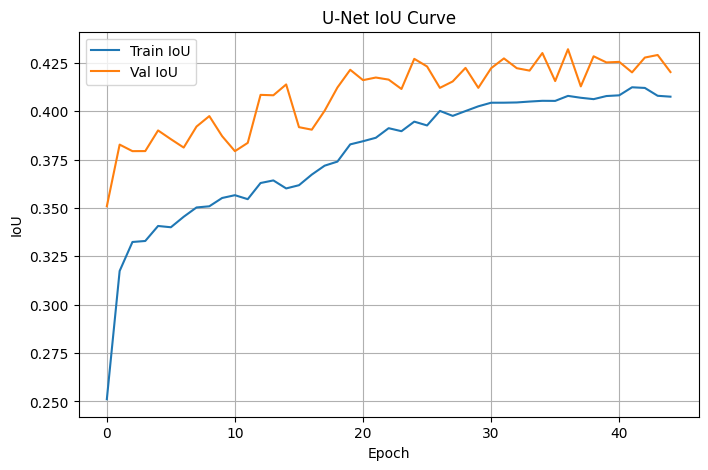

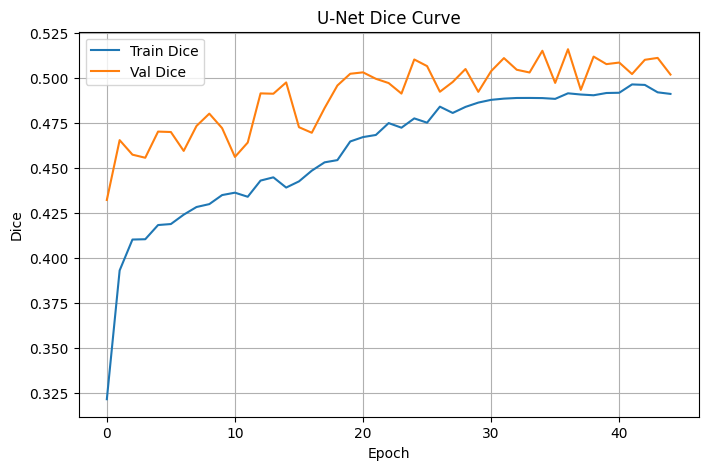

Saved plots to: /content/unet_final_results


In [26]:
import matplotlib.pyplot as plt

history_path = RESULT_DIR / "unet_training_history.json"

with open(history_path, "r", encoding="utf-8") as f:
    history_data = json.load(f)

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history_data["train_loss"], label="Train Loss")
plt.plot(history_data["val_loss"], label="Val Loss")
plt.title("U-Net Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(RESULT_DIR / "loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# IoU curve
plt.figure(figsize=(8, 5))
plt.plot(history_data["train_iou"], label="Train IoU")
plt.plot(history_data["val_iou"], label="Val IoU")
plt.title("U-Net IoU Curve")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid(True)
plt.savefig(RESULT_DIR / "iou_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# Dice curve
plt.figure(figsize=(8, 5))
plt.plot(history_data["train_dice"], label="Train Dice")
plt.plot(history_data["val_dice"], label="Val Dice")
plt.title("U-Net Dice Curve")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.grid(True)
plt.savefig(RESULT_DIR / "dice_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved plots to:", RESULT_DIR)

In [27]:
print("Files in result folder:")
print("-" * 50)

for file in sorted(RESULT_DIR.iterdir()):
    size_mb = file.stat().st_size / (1024 * 1024)
    print(f"{file.name} - {size_mb:.2f} MB")

Files in result folder:
--------------------------------------------------
README_unet_results.txt - 0.00 MB
best_unet_model.pth - 372.68 MB
dice_curve.png - 0.14 MB
iou_curve.png - 0.14 MB
last_unet_model.pth - 372.68 MB
loss_curve.png - 0.11 MB
unet_metrics_summary.json - 0.00 MB
unet_training_history.json - 0.02 MB
unet_weights_only.pth - 124.40 MB


In [28]:
import shutil

ZIP_PATH = "/content/unet_final_results"

zip_file = shutil.make_archive(
    base_name=ZIP_PATH,
    format="zip",
    root_dir=RESULT_DIR
)

print("Created zip file:")
print(zip_file)

Created zip file:
/content/unet_final_results.zip


In [29]:
from google.colab import files

files.download("/content/unet_final_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import os
import json
import torch
from pathlib import Path

CHECKPOINT_DIR = Path("/content/drive/MyDrive/tomato_unet_checkpoints")

BEST_MODEL_PATH = CHECKPOINT_DIR / "best_unet_model.pth"
LAST_MODEL_PATH = CHECKPOINT_DIR / "last_unet_model.pth"
WEIGHTS_ONLY_PATH = CHECKPOINT_DIR / "unet_weights_only.pth"
HISTORY_PATH = CHECKPOINT_DIR / "unet_training_history.json"

checkpoint = torch.load(BEST_MODEL_PATH, map_location="cpu")

with open(HISTORY_PATH, "r", encoding="utf-8") as f:
    history = json.load(f)

print("Loaded checkpoint:", BEST_MODEL_PATH)
print("Loaded history:", HISTORY_PATH)

Loaded checkpoint: /content/drive/MyDrive/tomato_unet_checkpoints/best_unet_model.pth
Loaded history: /content/drive/MyDrive/tomato_unet_checkpoints/unet_training_history.json


In [31]:
def get_file_size_mb(path):
    path = Path(path)
    if path.exists():
        return path.stat().st_size / (1024 * 1024)
    return None

print("=" * 60)
print("MODEL CHECKPOINT INFORMATION")
print("=" * 60)

print("Model name        : U-Net")
print("Encoder           :", checkpoint.get("encoder", "resnet50"))
print("Encoder weights   :", checkpoint.get("encoder_weights", "imagenet"))
print("Image size        :", checkpoint.get("image_size", 512))
print("Batch size        :", checkpoint.get("batch_size", "N/A"))
print("Learning rate     :", checkpoint.get("lr", "N/A"))

print("-" * 60)
print("Best epoch        :", checkpoint.get("epoch", "N/A"))
print("Best Val IoU      :", checkpoint.get("best_iou", "N/A"))

print("-" * 60)
print("Best model size   :", f"{get_file_size_mb(BEST_MODEL_PATH):.2f} MB")
print("Last model size   :", f"{get_file_size_mb(LAST_MODEL_PATH):.2f} MB" if LAST_MODEL_PATH.exists() else "Missing")
print("Weights only size :", f"{get_file_size_mb(WEIGHTS_ONLY_PATH):.2f} MB" if WEIGHTS_ONLY_PATH.exists() else "Missing")

MODEL CHECKPOINT INFORMATION
Model name        : U-Net
Encoder           : resnet50
Encoder weights   : imagenet
Image size        : 512
Batch size        : 4
Learning rate     : 0.0001
------------------------------------------------------------
Best epoch        : 37
Best Val IoU      : 0.4319887686634465
------------------------------------------------------------
Best model size   : 372.68 MB
Last model size   : 372.68 MB
Weights only size : 124.40 MB


In [32]:
best_epoch = checkpoint.get("epoch", None)

print("=" * 60)
print("BEST VALIDATION RESULT")
print("=" * 60)

if best_epoch is not None:
    idx = best_epoch - 1

    print("Best Epoch       :", best_epoch)
    print("Train Loss       :", round(history["train_loss"][idx], 4))
    print("Val Loss         :", round(history["val_loss"][idx], 4))
    print("Train IoU        :", round(history["train_iou"][idx], 4))
    print("Val IoU          :", round(history["val_iou"][idx], 4))
    print("Train Dice       :", round(history["train_dice"][idx], 4))
    print("Val Dice         :", round(history["val_dice"][idx], 4))
    print("Train Accuracy   :", round(history["train_accuracy"][idx], 4))
    print("Val Accuracy     :", round(history["val_accuracy"][idx], 4))
    print("Train Precision  :", round(history["train_precision"][idx], 4))
    print("Val Precision    :", round(history["val_precision"][idx], 4))
    print("Train Recall     :", round(history["train_recall"][idx], 4))
    print("Val Recall       :", round(history["val_recall"][idx], 4))
else:
    print("Không tìm thấy best epoch trong checkpoint.")

BEST VALIDATION RESULT
Best Epoch       : 37
Train Loss       : 0.3371
Val Loss         : 0.4381
Train IoU        : 0.4079
Val IoU          : 0.432
Train Dice       : 0.4916
Val Dice         : 0.5161
Train Accuracy   : 0.9927
Val Accuracy     : 0.9932
Train Precision  : 0.7338
Val Precision    : 0.7485
Train Recall     : 0.5305
Val Recall       : 0.5486


In [33]:
test_results = {
    "test_images_found": 1229,
    "test_masks_found": 1210,
    "test_valid_pairs": 1210,
    "test_missing_masks_skipped": 19,
    "loss": 0.4350,
    "iou": 0.4267,
    "dice": 0.5155,
    "accuracy": 0.9923,
    "precision": 0.7473,
    "recall": 0.5386
}

print("=" * 60)
print("TEST RESULT")
print("=" * 60)

print("Images found          :", test_results["test_images_found"])
print("Masks found           :", test_results["test_masks_found"])
print("Valid pairs           :", test_results["test_valid_pairs"])
print("Missing masks skipped :", test_results["test_missing_masks_skipped"])

print("-" * 60)
print("Test Loss             :", test_results["loss"])
print("Test IoU              :", test_results["iou"])
print("Test Dice             :", test_results["dice"])
print("Test Accuracy         :", test_results["accuracy"])
print("Test Precision        :", test_results["precision"])
print("Test Recall           :", test_results["recall"])

TEST RESULT
Images found          : 1229
Masks found           : 1210
Valid pairs           : 1210
Missing masks skipped : 19
------------------------------------------------------------
Test Loss             : 0.435
Test IoU              : 0.4267
Test Dice             : 0.5155
Test Accuracy         : 0.9923
Test Precision        : 0.7473
Test Recall           : 0.5386


In [34]:
import pandas as pd

summary_table = pd.DataFrame([
    ["Model", "U-Net"],
    ["Encoder", checkpoint.get("encoder", "resnet50")],
    ["Image Size", checkpoint.get("image_size", 512)],
    ["Best Epoch", checkpoint.get("epoch", "N/A")],
    ["Best Val IoU", round(checkpoint.get("best_iou", 0), 4)],
    ["Test Loss", test_results["loss"]],
    ["Test IoU", test_results["iou"]],
    ["Test Dice", test_results["dice"]],
    ["Test Accuracy", test_results["accuracy"]],
    ["Test Precision", test_results["precision"]],
    ["Test Recall", test_results["recall"]],
    ["Test Valid Pairs", test_results["test_valid_pairs"]],
    ["Missing Test Masks", test_results["test_missing_masks_skipped"]],
    ["Best Model Size MB", round(get_file_size_mb(BEST_MODEL_PATH), 2)]
], columns=["Metric", "Value"])

summary_table

,Metric,Value
0,Model,U-Net
1,Encoder,resnet50
2,Image Size,512
3,Best Epoch,37
4,Best Val IoU,0.432
5,Test Loss,0.435
6,Test IoU,0.4267
7,Test Dice,0.5155
8,Test Accuracy,0.9923
9,Test Precision,0.7473
